<a href="https://colab.research.google.com/github/ferdinandrafols/IA_LLMs/blob/main/aula6_retrieval_augmented_generation_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6: Introdução a RAG (Retrieval-Augmented Generation)

Objetivos:

- Entender o pipeline completo de um sistema RAG
- Implementar:
  - Chunking
  - Geração de embeddings
  - Busca vetorial por similaridade
  - Geração de resposta condicionada ao contexto recuperado
- Analisar como a recuperação influencia a qualidade da resposta


Nesta aula vamos usar o seguinte roteiro prático:

1. Criar uma mini base de conhecimento (docs).
2. Fazer *chunking* (segmentação) para obter unidades recuperáveis.
3. Gerar embeddings e implementar uma busca vetorial simples.
4. Montar o *contexto* (augmentation) com os chunks mais relevantes.
5. Passar o contexto para um modelo gerador (generator) e obter uma resposta (*RAG completo*).


## 1) Setup do ambiente


In [ ]:
# Se necessário, instale as seguintes dependências:
# !pip install -U sentence-transformers transformers torch scikit-learn numpy pandas matplotlib

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


## 2) Mini Base de Conhecimento


In [ ]:
# Mini base de conhecimento (exemplo didático).
# Dica: substitua por trechos do seu domínio (FAQ, políticas, docs, etc.).

docs = [
    {
        "id": "doc1",
        "text": '''
        A empresa utiliza arquitetura baseada em microserviços.
        Todos os serviços devem se comunicar via API REST autenticada.
        O deploy é realizado usando Kubernetes.
        '''
    },
    {
        "id": "doc2",
        "text": '''
        O modelo principal de NLP é baseado em transformers decoder-only.
        Para tarefas de busca semântica utilizamos modelos encoder-only.
        Embeddings são armazenados em banco vetorial.
        '''
    },
    {
        "id": "doc3",
        "text": '''
        A política de segurança exige autenticação multifator.
        Tokens JWT devem expirar em no máximo 1 hora.
        Logs devem ser armazenados por 90 dias.
        '''
    }
]


## 3) Chunking (segmentação) - construção de contexto

Nesta aula, vamos usar sentenças como chunks (simples e didático).  
Em produção, você normalmente usa chunking por **tamanho** (tokens/caracteres) + **overlap**.


In [ ]:
def split_sentences_pt(text: str) -> list[str]:
    # Segmentação simplificada (por ponto).
    return [s.strip() for s in text.split(".") if len(s.strip()) > 0]

rows = []
for doc in docs:
    sentences = split_sentences_pt(doc["text"])
    for sent in sentences:
        rows.append({
            "doc_id": doc["id"],
            "sentence": sent
        })

df = pd.DataFrame(rows)
df


,doc_id,sentence
0,doc1,A empresa utiliza arquitetura baseada em micro...
1,doc1,Todos os serviços devem se comunicar via API R...
2,doc1,O deploy é realizado usando Kubernetes
3,doc2,O modelo principal de NLP é baseado em transfo...
4,doc2,Para tarefas de busca semântica utilizamos mod...
5,doc2,Embeddings são armazenados em banco vetorial
6,doc3,A política de segurança exige autenticação mul...
7,doc3,Tokens JWT devem expirar em no máximo 1 hora
8,doc3,Logs devem ser armazenados por 90 dias


## 4) Gerar embeddings (Retriever, R do RAG)

Usaremos um modelo encoder-only do SentenceTransformers para gerar embeddings dos chunks.


In [ ]:
model_emb = SentenceTransformer("all-MiniLM-L6-v2")

sentences = df["sentence"].tolist()
embeddings = model_emb.encode(sentences)

df["embedding"] = list(embeddings)
df.head()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,doc_id,sentence,embedding
0,doc1,A empresa utiliza arquitetura baseada em micro...,"[-0.030749356, -0.008372812, -0.033830684, -0...."
1,doc1,Todos os serviços devem se comunicar via API R...,"[0.0045394567, 0.08075219, -0.09790498, -0.063..."
2,doc1,O deploy é realizado usando Kubernetes,"[0.007983925, 0.026449937, -0.032273848, -0.05..."
3,doc2,O modelo principal de NLP é baseado em transfo...,"[-0.08753842, 0.03104874, -0.004682832, -0.051..."
4,doc2,Para tarefas de busca semântica utilizamos mod...,"[-0.02181021, -0.027169319, -0.056348737, -0.0..."


## 5) Busca vetorial por similaridade (R do RAG)

Implementação minimalista com similaridade cosseno.  
(Em produção, isso vai para um índice/banco vetorial: FAISS, Milvus, Pinecone, Weaviate, pgvector, etc.)


In [ ]:
def retrieve(query: str, top_k: int = 3) -> pd.DataFrame:
    query_emb = model_emb.encode([query])
    matrix = np.vstack(df["embedding"].values)

    sims = cosine_similarity(query_emb, matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = df.iloc[top_idx].copy()
    results["score"] = sims[top_idx]
    return results

query = "Como funciona a autenticação?"
retrieve(query, top_k=3)


,doc_id,sentence,embedding,score
6,doc3,A política de segurança exige autenticação mul...,"[0.031269945, 0.02299102, -0.06889581, -0.0792...",0.402013
8,doc3,Logs devem ser armazenados por 90 dias,"[-0.028129576, 0.15457058, 0.0145603325, -0.01...",0.394104
5,doc2,Embeddings são armazenados em banco vetorial,"[-0.06827421, 0.021841114, -0.051524602, -0.03...",0.367755


## 6) Montando o contexto (Augmentation, A do RAG)

Agora agregamos os chunks recuperados em um bloco de texto que será injetado no prompt.


In [ ]:
def build_context(query: str, top_k: int = 3) -> str:
    retrieved = retrieve(query, top_k)
    context = "\n".join(retrieved["sentence"].tolist())
    return context

query = "Qual é a política de tokens?"
context = build_context(query, top_k=3)
print(context)


A política de segurança exige autenticação multifator
Embeddings são armazenados em banco vetorial
Tokens JWT devem expirar em no máximo 1 hora


## 7) Parte gerativa (Generation, G do RAG)

Aqui usamos um modelo causal pequeno para fins didáticos. Troque o distilgpt2 para o gemma 3 para melhores resultados.


In [ ]:
model_name = "distilgpt2" # Modelo pequeno para teste rápido
#model_name = "google/gemma-3-270m" # De melhor qualidade, mas download de 0.5G

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_gen = AutoModelForCausalLM.from_pretrained(model_name)

# distilgpt-2 não tem pad_token necessário para a geração
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 8) Pipeline RAG simples

1. Recupera chunks (Retriever)  
2. Monta contexto (Augmentation)  
3. Gera resposta condicionada (Generator)


In [ ]:
def rag_answer(query: str, top_k: int = 3, max_tokens: int = 150) -> str:
    context = build_context(query, top_k)

    prompt = f"""Responda à pergunta usando apenas o contexto abaixo.

Contexto:
{context}

Pergunta:
{query}

Resposta:
"""

    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model_gen.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

rag_answer("Como funciona a política de autenticação?", top_k=3)


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


'Responda à pergunta usando apenas o contexto abaixo.\n\nContexto:\nA política de segurança exige autenticação multifator\nLogs devem ser armazenados por 90 dias\nEmbeddings são armazenados em banco vetorial\n\nPergunta:\nComo funciona a política de autenticação?\n\nResposta:\nA política de autenticação é uma política de segurança que permite que os usuários de um sistema de segurança compartilhado (como o Microsoft Windows) autenticem-se para acessar o sistema.\n\nO Microsoft Windows é um sistema de segurança compartilhado que permite que os usuários de um sistema de segurança compartilhado (como o Microsoft Windows) autenticem-se para acessar o sistema.\n\nO Microsoft Windows é um sistema de segurança compartilhado que permite que os usuários de um sistema de segurança compartilhado (como o Microsoft Windows) autenticem-se para acessar o sistema.\n\nO Microsoft Windows é um sistema de segurança compartilhado que permite que os usuários de um sistema de segurança compartilhado (como o

## 9) Visualizando similaridade (conexão com Embeddings)

Vamos projetar os embeddings em 2D com PCA para observar agrupamentos.


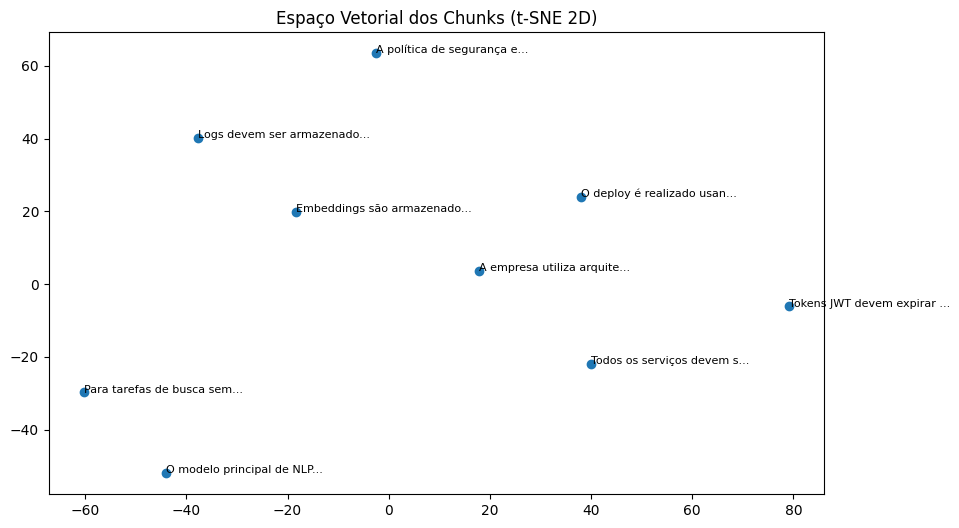

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Import TSNE
import matplotlib.pyplot as plt

X = np.vstack(df["embedding"].values)

# Use t-SNE instead of PCA
ts = TSNE(n_components=2, random_state=42, perplexity=5) # Added random_state for reproducibility and fixed perplexity
X2 = ts.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X2[:, 0], X2[:, 1])

for i, txt in enumerate(df["sentence"]):
    plt.annotate(txt[:25] + ("..." if len(txt) > 25 else ""), (X2[i, 0], X2[i, 1]), fontsize=8)

plt.title("Espaço Vetorial dos Chunks (t-SNE 2D)") # Update title
plt.show()

## 10) Experimentos

Tente rodar as células abaixo e discutir os resultados.

- O que acontece se `top_k = 1`?
- E se aumentarmos para `top_k = 5`?
- Faça uma pergunta fora do domínio da base (para ver como o sistema se comporta).
- Modifique os documentos e observe o impacto na resposta.
